<a href="https://colab.research.google.com/github/beingAnujChaudhary/Practical-Statistics-for-DS/blob/main/chapter_01_exploratory_data_analysis/01_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/Practical-Statistics-for-DS.git

# Move into repository
%cd /content/Practical-Statistics-for-DS

# Move into Chapter 1 folder
%cd chapter_01_exploratory_data_analysis

Mounted at /content/drive
Cloning into 'Practical-Statistics-for-DS'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 221 (delta 121), reused 102 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 28.86 MiB | 3.19 MiB/s, done.
Resolving deltas: 100% (121/121), done.
/content/Practical-Statistics-for-DS
/content/Practical-Statistics-for-DS/chapter_01_exploratory_data_analysis


# Chapter 1: Exploratory Data Analysis

**Book**: *Practical Statistics for Data Scientists, 2nd Edition*  
**Authors**: Peter Bruce, Andrew Bruce, Peter Gedeck  
**Implementation**: Python 3.12.10  
**Source Pages**: 1–46


---

## 📋 Chapter Overview

Exploratory Data Analysis (EDA) is the process of examining, summarising, and visualising data **before** applying statistical models or machine learning algorithms. Pioneered by John Tukey in 1977, EDA focuses on understanding data through summary statistics and visualisations before formal modelling.

**The primary goal of EDA is to:**
- Understand the structure and shape of the data
- Identify patterns, trends, and anomalies
- Detect missing values and outliers
- Understand distributions and relationships between variables
- Generate hypotheses for further analysis

> ⚠️ EDA is one of the most important steps in any data science workflow. Poor understanding of data almost always leads to poor modelling decisions.

---

## 🎯 Learning Objectives

By the end of this notebook, you should be able to:
- Understand different types of structured data (numeric, categorical, binary, ordinal)
- Work with rectangular data structures (pandas DataFrames)
- Calculate and interpret estimates of location (mean, median, trimmed mean, weighted mean)
- Calculate and interpret estimates of variability (variance, SD, IQR, MAD)
- Visualise data distributions using histograms, boxplots, and density plots
- Analyse binary and categorical data
- Measure and visualise correlation between variables
- Explore relationships between multiple variables

---

## 🔑 Key Concepts Summary

| Concept | Description | Python Implementation |
|---|---|---|
| Mean | Arithmetic average of values | `df.mean()` |
| Median | Middle value in sorted data (robust to outliers) | `df.median()` |
| Trimmed Mean | Mean after dropping extreme values from both ends | `scipy.stats.trim_mean()` |
| Weighted Mean | Mean where observations carry different importance | `np.average()` |
| Standard Deviation | Average variability from the mean (original units) | `df.std()` |
| IQR | Spread of the middle 50% of data (Q3 − Q1) | `df.quantile()` |
| MAD | Robust measure of spread | `statsmodels.robust.mad` |
| Boxplot | Visual summary of distribution + outlier detection | `sns.boxplot()` |
| Histogram | Distribution of numerical data using bins | `sns.histplot()` |
| Density Plot | Smoothed version of histogram (KDE) | `sns.kdeplot()` |
| Pearson Correlation | Strength of linear relationship (−1 to +1) | `df.corr()` |
| Scatterplot | Relationship between two numerical variables | `sns.scatterplot()` |


In [5]:
# ## 0. Setup and Imports

import os
import sys
import warnings

warnings.filterwarnings("ignore")

# Try importing local utility module
try:
    from utils.notebook_setup import *
    print("✓ Imported notebook_setup.py")

except ModuleNotFoundError:
    print("⚠ utils.notebook_setup not found")
    print("Using fallback imports")

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

# Extra imports
from scipy.stats import (
    trim_mean,
    linregress
)

from statsmodels.robust import mad

# Reproducibility
np.random.seed(42)

# Pandas display options
pd.set_option(
    'display.max_columns',
    None
)

pd.set_option(
    'display.width',
    120
)

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)

print("✓ All imports successful")
print(
    f"Python version: {sys.version.split()[0]}"
)
print(
    f"NumPy version: {np.__version__}"
)
print(
    f"Pandas version: {pd.__version__}"
)

ModuleNotFoundError: No module named 'utils'

In [ ]:
# ## 1. Load the State Data
# We'll use the state.csv dataset from the book containing US state population
# and murder rates

# Try to load from local datasets first, then fall back to book repo
data_path = '../datasets/raw/state.csv'
if not os.path.exists(data_path):
    # Fallback: load from book's GitHub repo
    url = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv'
    print(f"Local file not found. Loading from GitHub...")
    state = pd.read_csv(url)
else:
    state = pd.read_csv(data_path)

print(f"Dataset shape: {state.shape}")
print(f"Columns: {state.columns.tolist()}")
state.head(10)


---

## 1. Elements of Structured Data

The book distinguishes between several key data types:

### Data Types
- **Numeric Data**
  - *Continuous*: Can take any value in an interval (e.g., temperature, time)
  - *Discrete*: Integer values, counts (e.g., number of customers)
- **Categorical Data**
  - Takes a fixed set of values (e.g., state names, product categories)
  - *Binary*: Special case with two values (0/1, yes/no, true/false)
  - *Ordinal*: Categories with explicit ordering (e.g., ratings 1–5)

**Why Data Types Matter:**
- Determines appropriate visualisations
- Influences statistical model selection
- Affects computational performance in software


In [ ]:
# ### 1.1 Inspect Data Types

print("Current data types:")
print(state.dtypes)
print(f"\nMemory usage: {state.memory_usage(deep=True).sum() / 1024:.2f} KB")


Current data types:
State            object
Population        int64
Murder.Rate     float64
Abbreviation     object
dtype: object

Memory usage: 6.21 KB


In [ ]:
# ### 1.2 Convert to Appropriate Types
# Abbreviation and State should be categorical, not object

state['Abbreviation'] = state['Abbreviation'].astype('category')
state['State'] = state['State'].astype('category')

# Verify the conversion
print("Updated data types for categorical columns:")
print(state[['State', 'Abbreviation']].dtypes)
print(f"\nNumber of unique states: {state['State'].nunique()}")
print(f"Number of unique abbreviations: {state['Abbreviation'].nunique()}")


Updated data types for categorical columns:
State           category
Abbreviation    category
dtype: object

Number of unique states: 50
Number of unique abbreviations: 50


## 2. Rectangular Data

### Working with pandas DataFrames

The basic structure for analysis:
- **Rows** = Records (cases, observations, instances) — here, individual states
- **Columns** = Features (variables, predictors, attributes) — Population, Murder.Rate, Abbreviation
- **Data Frame** = The standard format in Python (pandas) and R

**Key Terminology:**
- **Feature / Predictor**: Input variable used for prediction
- **Outcome / Target**: Variable being predicted
- **Index**: Row identifier for efficient queries


In [ ]:
# ### 2.1 Basic DataFrame Operations

# Summary statistics for numeric columns
print("Summary statistics for numeric columns:")
state.describe()


Summary statistics for numeric columns:


,Population,Murder.Rate
count,50.00,50.00
mean,6162876.30,4.07
std,6848235.35,1.92
min,563626.00,0.90
25%,1833004.25,2.42
50%,4436369.50,4.00
75%,6680312.25,5.55
max,37253956.00,10.30


In [ ]:
# ### 2.2 DataFrame Info

state.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   State         50 non-null     category
 1   Population    50 non-null     int64   
 2   Murder.Rate   50 non-null     float64 
 3   Abbreviation  50 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 5.9 KB


In [ ]:
# ### 2.3 Quick Data Quality Check

print("Missing values per column:")
print(state.isnull().sum())
print(f"\nDuplicate rows: {state.duplicated().sum()}")


Missing values per column:
State           0
Population      0
Murder.Rate     0
Abbreviation    0
dtype: int64

Duplicate rows: 0


## 3. Estimates of Location (Central Tendency)

Measures of location describe the **centre** of the data — finding a "typical value."

| Metric | Formula | When to Use | Robust to Outliers? |
|---|---|---|---|
| **Mean** | \(\bar{x} = \frac{\sum x_i}{n}\) | Symmetric distributions | ❌ No |
| **Median** | Middle value of sorted data | Skewed distributions | ✅ Yes |
| **Trimmed Mean** | Mean after dropping p% from each end | Compromise between mean and median | ✅ Yes |
| **Weighted Mean** | \(\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}\) | Observations have different importance | ❌ No |

> 💡 **Key Insight from the Book:** For state population data, Mean > Trimmed Mean > Median indicates **right-skewed data** with high outliers pulling the mean upward.


In [ ]:
# ### 3.1 Population: Mean vs Median vs Trimmed Mean

population = state['Population']

mean_pop = population.mean()
median_pop = population.median()
trimmed_10 = trim_mean(population, 0.10)

print("Population Estimates of Location:")
print(f"  Mean:               {mean_pop:>12,.0f}")
print(f"  Median:             {median_pop:>12,.0f}")
print(f"  10% Trimmed Mean:   {trimmed_10:>12,.0f}")
print(f"\n  Mean > Trimmed > Median → Right-skewed distribution")


Population Estimates of Location:
  Mean:                  6,162,876
  Median:                4,436,370
  10% Trimmed Mean:      4,783,697

  Mean > Trimmed > Median → Right-skewed distribution


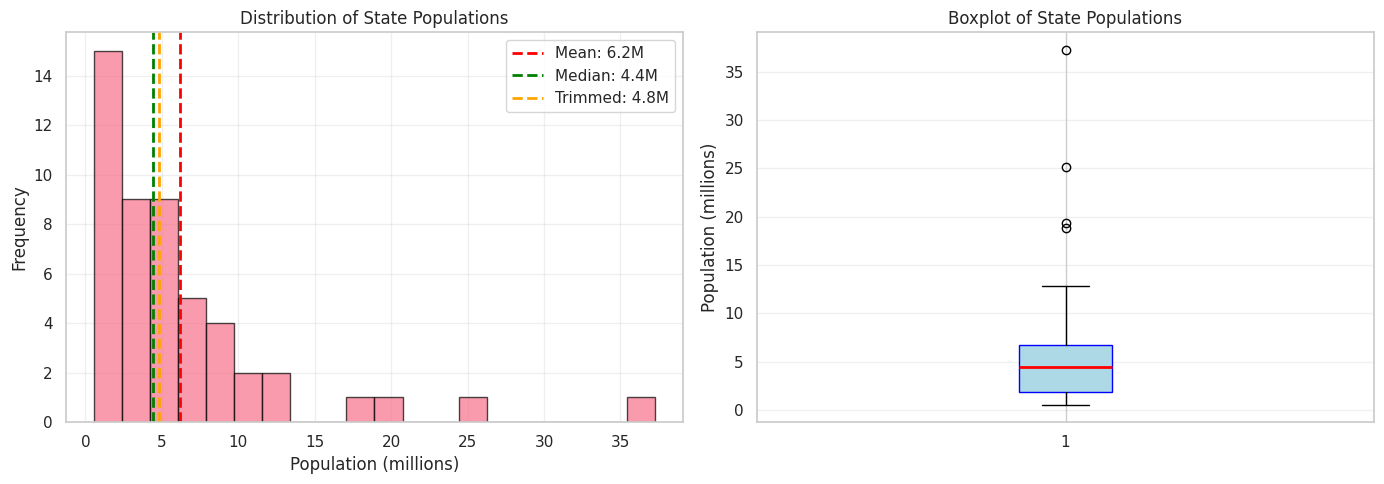


👉 The histogram and boxplot clearly show right-skewness.
   A few very large states (like California, Texas) pull the mean up.


In [ ]:
# ### 3.2 Visualise: Why Mean ≠ Median?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with location estimates
axes[0].hist(population / 1_000_000, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(mean_pop / 1_000_000, color='red', linestyle='--',
                linewidth=2, label=f'Mean: {mean_pop/1_000_000:.1f}M')
axes[0].axvline(median_pop / 1_000_000, color='green', linestyle='--',
                linewidth=2, label=f'Median: {median_pop/1_000_000:.1f}M')
axes[0].axvline(trimmed_10 / 1_000_000, color='orange', linestyle='--',
                linewidth=2, label=f'Trimmed: {trimmed_10/1_000_000:.1f}M')
axes[0].set_xlabel('Population (millions)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of State Populations')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot for context
axes[1].boxplot(population / 1_000_000, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Population (millions)')
axes[1].set_title('Boxplot of State Populations')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n👉 The histogram and boxplot clearly show right-skewness.")
print("   A few very large states (like California, Texas) pull the mean up.")


In [ ]:
# ### 3.3 Weighted Mean for Murder Rate
# When computing average murder rate, we should weight by population —
# a murder in California should count more than a murder in Wyoming

murder_rate = state['Murder.Rate']
weights = state['Population']

# Simple (unweighted) mean
unweighted_mean = murder_rate.mean()
print(f"Unweighted mean murder rate:     {unweighted_mean:.2f} per 100,000")

# Weighted mean (population-weighted)
weighted_mean = np.average(murder_rate, weights=weights)
print(f"Population-weighted mean rate:   {weighted_mean:.2f} per 100,000")

# Weighted median (using wquantiles if available)
try:
    import wquantiles
    weighted_median = wquantiles.median(murder_rate, weights=weights)
    print(f"Population-weighted median rate: {weighted_median:.2f} per 100,000")
except ImportError:
    print("\n⚠️ wquantiles not installed — weighted median skipped")
    print("   Install with: pip install wquantiles")


Unweighted mean murder rate:     4.07 per 100,000
Population-weighted mean rate:   4.45 per 100,000

⚠️ wquantiles not installed — weighted median skipped
   Install with: pip install wquantiles


## 4. Estimates of Variability (Dispersion)

Measures of variability describe how **spread out** the data is.

| Metric | Formula | Interpretation | Robust? |
|---|---|---|---|
| **Variance** | \(s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}\) | Average squared deviation from mean | ❌ |
| **Standard Deviation** | \(s = \sqrt{s^2}\) | Typical deviation from mean (original units) | ❌ |
| **IQR** | \(Q3 - Q1\) | Spread of middle 50% | ✅ |
| **MAD** | Median(\(|x_i - \text{median}(x)|\)) | Robust measure of spread | ✅ |
| **Range** | \(\max - \min\) | Total spread | ❌ |

> 💡 For skewed distributions, **prefer IQR or MAD** over standard deviation.


In [ ]:
# ### 4.1 Population Variability Metrics

Q1 = population.quantile(0.25)
Q3 = population.quantile(0.75)
IQR = Q3 - Q1

print("Population Variability Estimates:")
print(f"  Standard Deviation:     {population.std():>12,.0f}")
print(f"  Variance:               {population.var():>12,.0f}")
print(f"  IQR (Q3 − Q1):          {IQR:>12,.0f}")
print(f"  MAD (robust):           {mad(population):>12,.0f}")
print(f"  Range (Max − Min):      {population.max() - population.min():>12,.0f}")
print(f"\n  Coefficient of Variation (SD/Mean): {population.std()/population.mean():.2%}")


Population Variability Estimates:
  Standard Deviation:        6,848,235
  Variance:               46,898,327,373,394
  IQR (Q3 − Q1):             4,847,308
  MAD (robust):              3,849,876
  Range (Max − Min):        36,690,330

  Coefficient of Variation (SD/Mean): 111.12%


Boxplot values (in millions):
  Min (lower whisker):  0.56
  Q1 (25th percentile): 1.83
  Median (50th):        4.44
  Q3 (75th percentile): 6.68
  Max (upper whisker):  37.25

🔴 Outliers detected (4 states):
     California: 37.3M
     Florida: 18.8M
     New York: 19.4M
     Texas: 25.1M


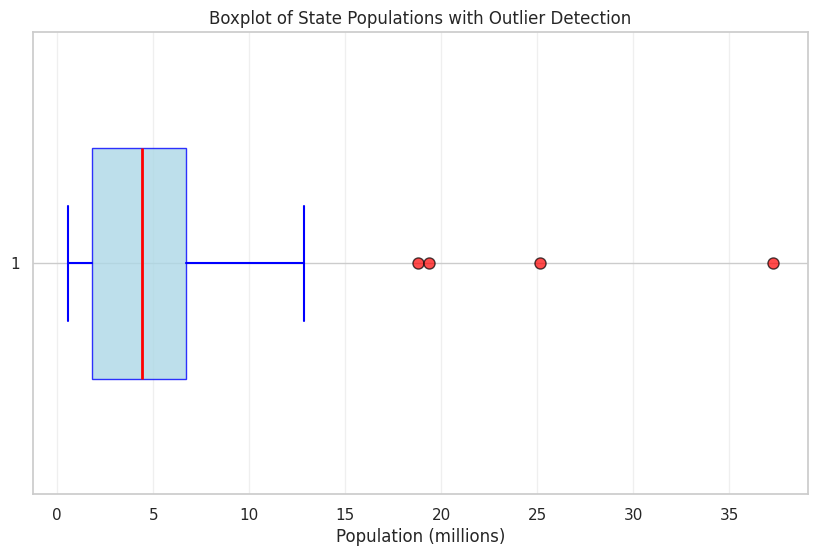

In [ ]:
# ### 4.2 Boxplot with Outlier Annotation

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(population / 1_000_000, vert=False, patch_artist=True,
                widths=0.5,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.8),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=8, alpha=0.7))

ax.set_xlabel('Population (millions)')
ax.set_title('Boxplot of State Populations with Outlier Detection')
ax.grid(axis='x', alpha=0.3)

# Annotate key values
print("Boxplot values (in millions):")
print(f"  Min (lower whisker):  {population.min() / 1_000_000:.2f}")
print(f"  Q1 (25th percentile): {Q1 / 1_000_000:.2f}")
print(f"  Median (50th):        {population.median() / 1_000_000:.2f}")
print(f"  Q3 (75th percentile): {Q3 / 1_000_000:.2f}")
print(f"  Max (upper whisker):  {population.max() / 1_000_000:.2f}")

# Identify outliers (1.5 × IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = state[(population < lower_bound) | (population > upper_bound)]
if len(outliers) > 0:
    print(f"\n🔴 Outliers detected ({len(outliers)} states):")
    for _, row in outliers.iterrows():
        print(f"     {row['State']}: {row['Population']/1_000_000:.1f}M")
else:
    print("\n✅ No outliers detected")


## 5. Exploring the Data Distribution

Understanding distributions helps identify skewness, symmetry, multimodality, and unusual observations.

### Key Visualisation Tools:
- **Histogram**: Divides data into bins; shows frequency per bin
- **Density Plot**: Smoothed version of histogram (KDE)
- **Boxplot**: Shows quartiles and outliers
- **QQ-Plot**: Assesses normality by comparing to theoretical quantiles


In [ ]:
# ### 5.1 Percentiles of Murder Rate

murder_rate = state['Murder.Rate']

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print("Murder Rate Percentiles (per 100,000 population):")
print(f"{'Percentile':<15} {'Value':>8}")
print("-" * 25)
for p in percentiles:
    value = murder_rate.quantile(p / 100)
    print(f"{p}th percentile:     {value:>8.2f}")


Murder Rate Percentiles (per 100,000 population):
Percentile         Value
-------------------------
1th percentile:         1.24
5th percentile:         1.60
10th percentile:         1.89
25th percentile:         2.42
50th percentile:         4.00
75th percentile:         5.55
90th percentile:         6.01
95th percentile:         6.51
99th percentile:         9.47


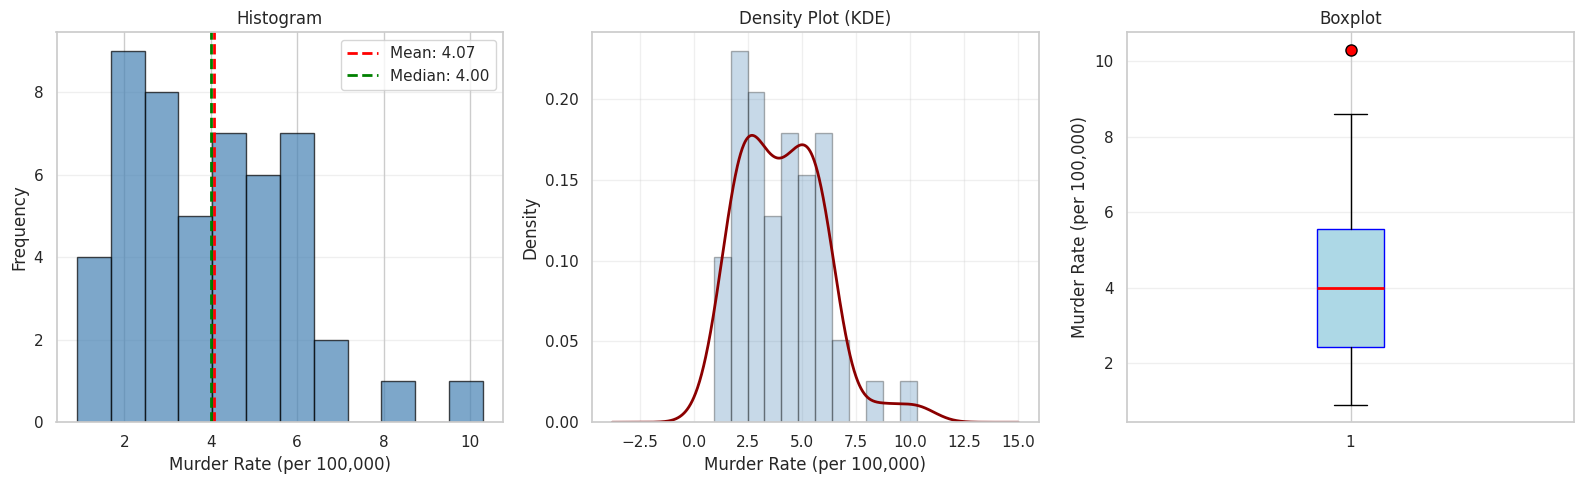

Skewness: 0.781
→ Right-skewed (positive skew)


In [ ]:
# ### 5.2 Histogram and Density Plot Comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram (counts)
axes[0].hist(murder_rate, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(murder_rate.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {murder_rate.mean():.2f}')
axes[0].axvline(murder_rate.median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {murder_rate.median():.2f}')
axes[0].set_xlabel('Murder Rate (per 100,000)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Density plot
axes[1].hist(murder_rate, bins=12, edgecolor='black', alpha=0.3,
             density=True, color='steelblue')
murder_rate.plot.kde(ax=axes[1], linewidth=2, color='darkred')
axes[1].set_xlabel('Murder Rate (per 100,000)')
axes[1].set_ylabel('Density')
axes[1].set_title('Density Plot (KDE)')
axes[1].grid(alpha=0.3)

# Boxplot
axes[2].boxplot(murder_rate, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[2].set_ylabel('Murder Rate (per 100,000)')
axes[2].set_title('Boxplot')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness assessment
skewness = murder_rate.skew()
print(f"Skewness: {skewness:.3f}")
if abs(skewness) < 0.5:
    print("→ Approximately symmetric")
elif skewness > 0:
    print("→ Right-skewed (positive skew)")
else:
    print("→ Left-skewed (negative skew)")


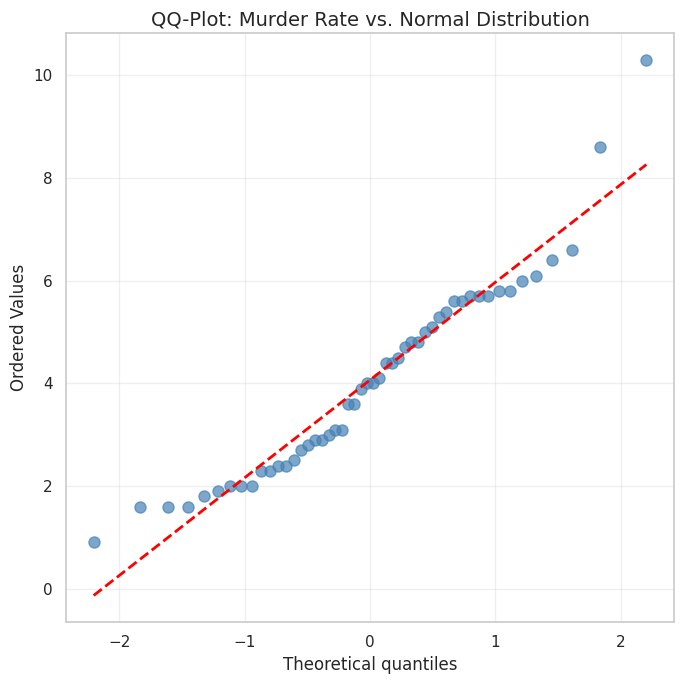


📊 QQ-Plot Interpretation Guide:
  • Points close to diagonal line → approximately normal
  • Curved pattern (U-shape or S-shape) → skewness present
  • S-shaped pattern → heavy or light tails
  • Points deviating at ends → outliers or long tails


In [ ]:
# ### 5.3 QQ-Plot: Assessing Normality

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(murder_rate, dist="norm", plot=ax)
ax.set_title('QQ-Plot: Murder Rate vs. Normal Distribution', fontsize=14)
ax.get_lines()[0].set(marker='o', markersize=8, alpha=0.7, color='steelblue')
ax.get_lines()[1].set(color='red', linewidth=2, linestyle='--')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 QQ-Plot Interpretation Guide:")
print("  • Points close to diagonal line → approximately normal")
print("  • Curved pattern (U-shape or S-shape) → skewness present")
print("  • S-shaped pattern → heavy or light tails")
print("  • Points deviating at ends → outliers or long tails")


## 6. Exploring Binary and Categorical Data

For categorical variables, we use:
- **Mode**: Most frequently occurring category
- **Proportions / Percentages**: For each category
- **Bar Charts**: Categories on x-axis, frequency on y-axis

> ⚠️ Pie charts are generally discouraged — bar charts are more informative for comparing proportions.


In [ ]:
# ### 6.1 Create a Binary Variable: High Murder Rate

# Create binary indicator: above or below median murder rate
state['HighMurder'] = (state['Murder.Rate'] > state['Murder.Rate'].median()).astype(int)

print("Binary Variable — High Murder Rate:")
print(f"  Mode: {state['HighMurder'].mode()[0]} ({'Above median' if state['HighMurder'].mode()[0]==1 else 'Below median'})")
print(f"  Proportion above median: {state['HighMurder'].mean():.1%}")
print(f"  Expected value (mean of binary): {state['HighMurder'].mean():.3f}")
print(f"\n  Value counts:")
print(f"    0 (Low):  {state['HighMurder'].value_counts().get(0, 0)}")
print(f"    1 (High): {state['HighMurder'].value_counts().get(1, 0)}")


Binary Variable — High Murder Rate:
  Mode: 0 (Below median)
  Proportion above median: 48.0%
  Expected value (mean of binary): 0.480

  Value counts:
    0 (Low):  26
    1 (High): 24


In [ ]:
# ### 6.2 Categorical Data: Murder Rate Quartiles

# Group states into murder rate quartiles
state['MurderQuartile'] = pd.qcut(
    state['Murder.Rate'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

# Frequency table
print("Frequency Table — Murder Rate Quartiles:")
freq_table = state['MurderQuartile'].value_counts().sort_index()
print(freq_table)
print(f"\nProportions:")
print((freq_table / len(state) * 100).round(1).astype(str) + '%')


Frequency Table — Murder Rate Quartiles:
MurderQuartile
Q1 (Lowest)     13
Q2              13
Q3              11
Q4 (Highest)    13
Name: count, dtype: int64

Proportions:
MurderQuartile
Q1 (Lowest)     26.0%
Q2              26.0%
Q3              22.0%
Q4 (Highest)    26.0%
Name: count, dtype: object


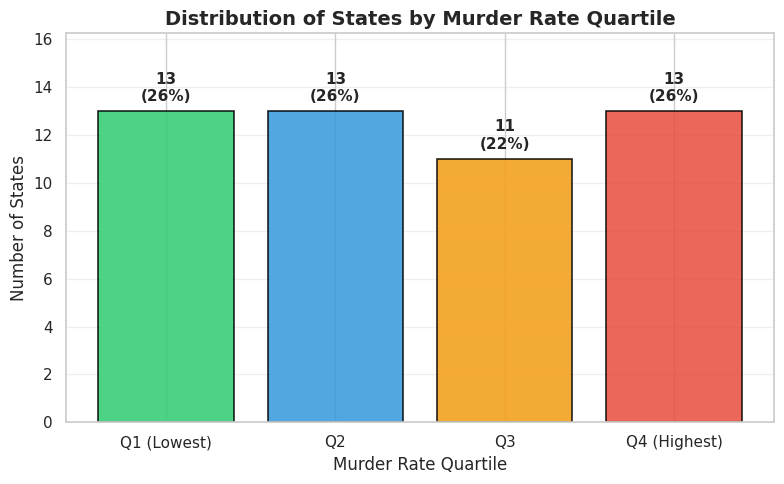

In [ ]:
# ### 6.3 Bar Chart Visualisation

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(freq_table.index, freq_table.values,
              color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on bars
for bar, count in zip(bars, freq_table.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{int(count)}\n({count/len(state)*100:.0f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Murder Rate Quartile', fontsize=12)
ax.set_ylabel('Number of States', fontsize=12)
ax.set_title('Distribution of States by Murder Rate Quartile', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(freq_table.values) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Correlation

Correlation measures the strength of the **linear** association between numerical variables.

**Pearson Correlation Coefficient (r):**
\[ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{(n-1) s_x s_y} \]

**Range:** −1 to +1

| Value | Interpretation |
|---|---|
| +1 | Perfect positive linear relationship |
| 0 | No linear relationship |
| −1 | Perfect negative linear relationship |

> ⚠️ **Critical Warnings:**
> - Correlation does **not** imply causation.
> - Pearson correlation measures **linear relationships only**.
> - \(r\) is sensitive to outliers.


In [ ]:
# ### 7.1 Correlation: Population vs. Murder Rate

# Pearson correlation
pearson_r = state['Population'].corr(state['Murder.Rate'])

# Spearman (rank-based, more robust to outliers)
spearman_r = state['Population'].corr(state['Murder.Rate'], method='spearman')

print("Correlation: Population vs. Murder Rate")
print(f"  Pearson r:  {pearson_r:+.3f}")
print(f"  Spearman ρ: {spearman_r:+.3f}")
print(f"\n  → {'Weak' if abs(pearson_r) < 0.3 else 'Moderate' if abs(pearson_r) < 0.7 else 'Strong'} ", end='')
print(f"{'positive' if pearson_r > 0 else 'negative'} linear relationship")


Correlation: Population vs. Murder Rate
  Pearson r:  +0.182
  Spearman ρ: +0.349

  → Weak positive linear relationship


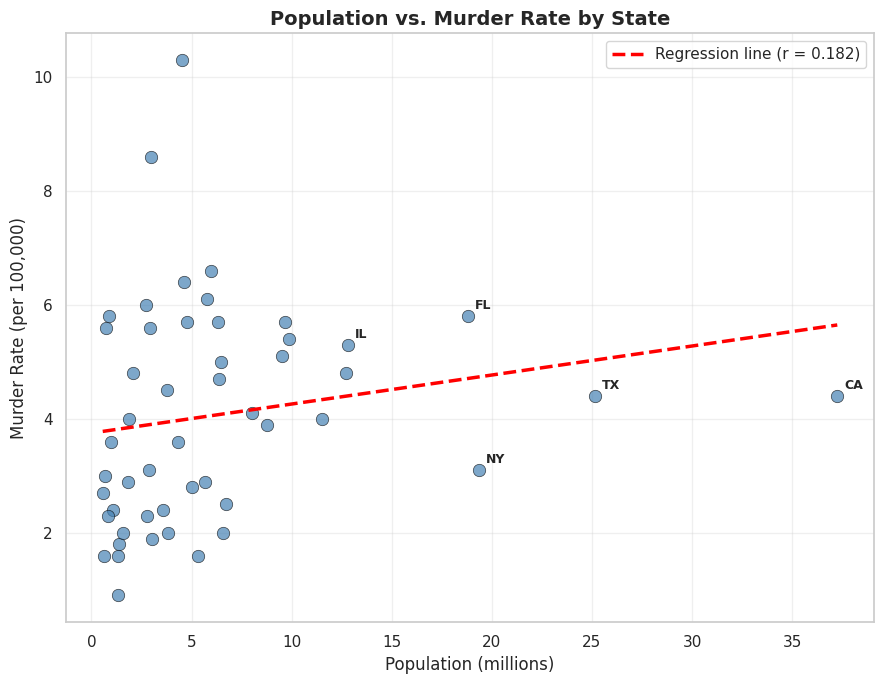


Regression Equation:
  MurderRate = 3.75 + (0.0509) × Population(millions)
  R² = 0.033
  p-value = 0.2057 (not significant)


In [ ]:
# ### 7.2 Scatterplot with Regression Line

fig, ax = plt.subplots(figsize=(9, 7))

pop_millions = state['Population'] / 1_000_000

ax.scatter(pop_millions, murder_rate, alpha=0.7, s=80,
           edgecolors='black', linewidth=0.5, c='steelblue')

# Add regression line with confidence
slope, intercept, r_value, p_value, std_err = linregress(pop_millions, murder_rate)
x_range = np.linspace(pop_millions.min(), pop_millions.max(), 100)
y_pred = intercept + slope * x_range
ax.plot(x_range, y_pred, 'r--', linewidth=2.5,
        label=f'Regression line (r = {r_value:.3f})')

# Annotate select states
top_states = state.nlargest(5, 'Population')
for _, row in top_states.iterrows():
    ax.annotate(row['Abbreviation'],
                (row['Population'] / 1_000_000, row['Murder.Rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Population (millions)', fontsize=12)
ax.set_ylabel('Murder Rate (per 100,000)', fontsize=12)
ax.set_title('Population vs. Murder Rate by State', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRegression Equation:")
print(f"  MurderRate = {intercept:.2f} + ({slope:.4f}) × Population(millions)")
print(f"  R² = {r_value**2:.3f}")
print(f"  p-value = {p_value:.4f} {'(statistically significant)' if p_value < 0.05 else '(not significant)'}")


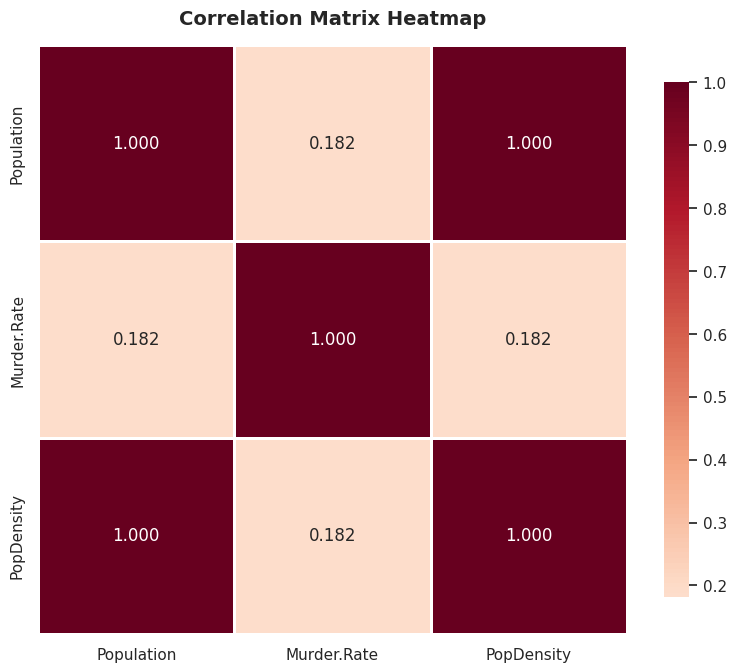


Correlation Matrix:
             Population  Murder.Rate  PopDensity
Population         1.00         0.18        1.00
Murder.Rate        0.18         1.00        0.18
PopDensity         1.00         0.18        1.00


In [ ]:
# ### 7.3 Correlation Matrix Heatmap

# Create a few derived numeric variables for richer matrix
state['PopDensity'] = state['Population'] / 1_000_000  # millions

numeric_cols = ['Population', 'Murder.Rate', 'PopDensity']
corr_matrix = state[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.8, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12})
ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


## 8. Exploring Two or More Variables

### Visualising Relationships by Data Type

| Relationship | Recommended Visualisation |
|---|---|
| Numeric vs. Numeric | Scatterplot, hexbin plot |
| Categorical vs. Categorical | Contingency table, stacked bar chart |
| Numeric vs. Categorical | Side-by-side boxplots, violin plots |
| Multiple Variables | Faceting, colour/shape encoding |


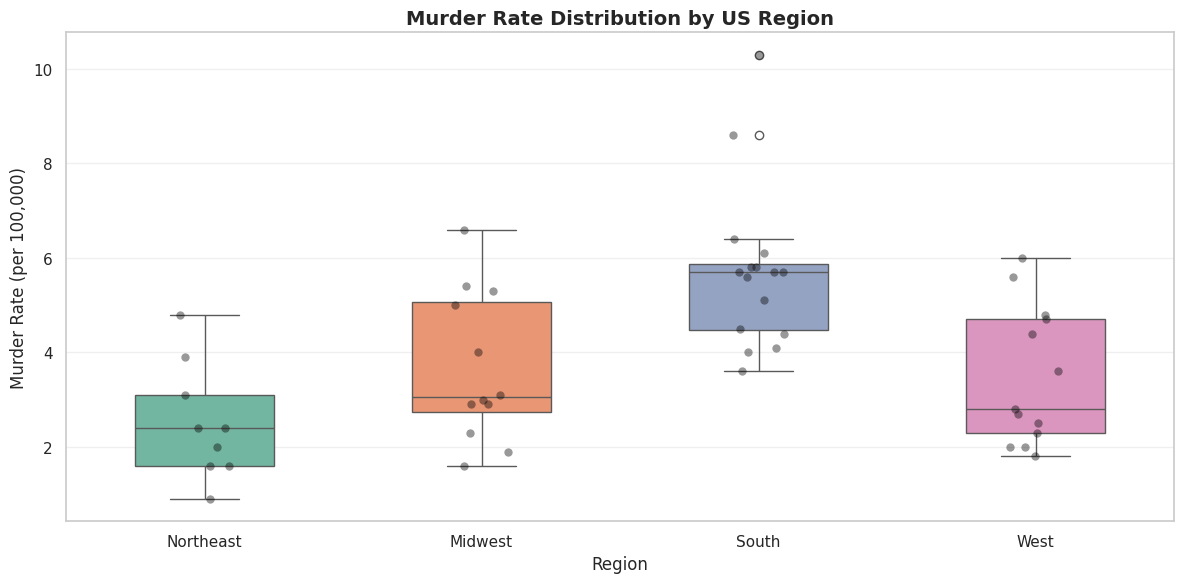


Murder Rate Summary by Region:
           count  mean  std  min  25%  50%  75%   max
Region                                               
Midwest    12.00  3.67 1.58 1.60 2.75 3.05 5.08  6.60
Northeast   9.00  2.52 1.23 0.90 1.60 2.40 3.10  4.80
South      16.00  5.71 1.70 3.60 4.47 5.70 5.88 10.30
West       13.00  3.48 1.46 1.80 2.30 2.80 4.70  6.00


In [ ]:
# ### 8.1 Boxplot: Murder Rate by Region (Simulated)
# Since our data doesn't have regions, we create one for demonstration

# Map first letter of abbreviation to approximate region
region_map = {
    'AL': 'South', 'AK': 'West', 'AZ': 'West', 'AR': 'South',
    'CA': 'West', 'CO': 'West', 'CT': 'Northeast', 'DE': 'South',
    'FL': 'South', 'GA': 'South', 'HI': 'West', 'ID': 'West',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'KY': 'South', 'LA': 'South', 'ME': 'Northeast', 'MD': 'South',
    'MA': 'Northeast', 'MI': 'Midwest', 'MN': 'Midwest', 'MS': 'South',
    'MO': 'Midwest', 'MT': 'West', 'NE': 'Midwest', 'NV': 'West',
    'NH': 'Northeast', 'NJ': 'Northeast', 'NM': 'West', 'NY': 'Northeast',
    'NC': 'South', 'ND': 'Midwest', 'OH': 'Midwest', 'OK': 'South',
    'OR': 'West', 'PA': 'Northeast', 'RI': 'Northeast', 'SC': 'South',
    'SD': 'Midwest', 'TN': 'South', 'TX': 'South', 'UT': 'West',
    'VT': 'Northeast', 'VA': 'South', 'WA': 'West', 'WV': 'South',
    'WI': 'Midwest', 'WY': 'West'
}
state['Region'] = state['Abbreviation'].map(region_map)

fig, ax = plt.subplots(figsize=(12, 6))
region_order = ['Northeast', 'Midwest', 'South', 'West']
sns.boxplot(data=state, x='Region', y='Murder.Rate', order=region_order,
            palette='Set2', width=0.5)
sns.stripplot(data=state, x='Region', y='Murder.Rate', order=region_order,
              color='black', alpha=0.4, size=6, jitter=True)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Murder Rate (per 100,000)', fontsize=12)
ax.set_title('Murder Rate Distribution by US Region', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics by region
print("\nMurder Rate Summary by Region:")
print(state.groupby('Region', observed=True)['Murder.Rate'].describe().round(2))


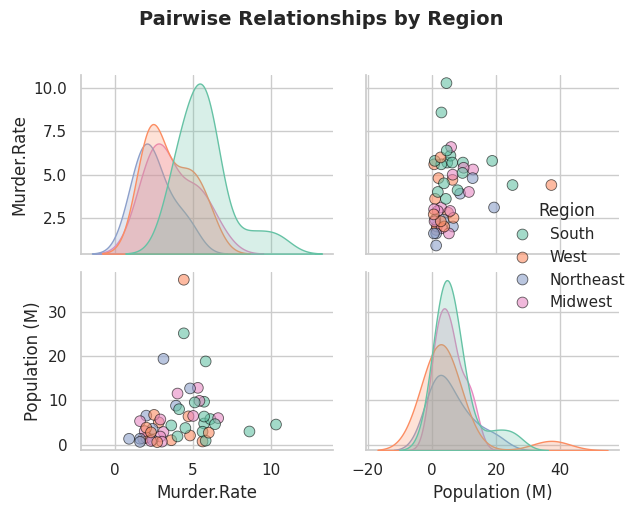

In [ ]:
# ### 8.2 Pairplot for Multiple Numeric Variables

# Select and prepare columns for pairplot
plot_cols = ['Population', 'Murder.Rate', 'PopDensity']
plot_data = state[plot_cols].copy()
plot_data['Population (M)'] = plot_data['Population'] / 1_000_000
plot_data = plot_data.drop(columns=['Population', 'PopDensity'])
plot_data['Region'] = state['Region']

g = sns.pairplot(plot_data, hue='Region', diag_kind='kde',
                 palette='Set2', plot_kws={'alpha': 0.6, 's': 60, 'edgecolor': 'k'},
                 height=2.5)
g.fig.suptitle('Pairwise Relationships by Region', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Machine Learning Relevance

EDA is critical in machine learning because it helps:

### 🎯 Improve Feature Engineering
Understanding distributions guides decisions about:
- Log transformations for skewed data
- Normalisation and standardisation
- Binning continuous variables

### 🔍 Detect Bad Data
EDA identifies before modelling:
- Missing values and their patterns
- Duplicate records
- Outliers that may distort models
- Inconsistent categories

### 🛡️ Prevent Modelling Mistakes
Without EDA:
- Poor features are selected
- Wrong assumptions are made (e.g., normality)
- Models overfit noisy data

### 🔗 Understand Feature Relationships
Correlation analysis helps:
- Remove redundant features
- Reduce multicollinearity
- Improve model stability and interpretability


## 📊 Key Takeaways

1. **Data types matter**: Always check and set appropriate dtypes in pandas — they affect computation and visualisation choices.

2. **Mean vs. Median**: Use median for skewed distributions; mean is highly sensitive to outliers. For state populations, Mean (6.16M) > Median (4.44M) → right-skewed.

3. **Variability metrics depend on context**:
   - SD for symmetric data
   - IQR/MAD for skewed or outlier-prone data
   - Standard error measures estimate precision (covered in Chapter 2)

4. **Visualisation is essential**: Histograms, boxplots, and scatterplots reveal patterns that numbers alone miss. Always plot before modelling.

5. **Correlation ≠ Causation**: Always consider confounding variables. Two variables may move together without one causing the other.

6. **Weighting matters**: Use weighted averages when observations represent different population sizes. An unweighted mean of state murder rates gives Wyoming the same weight as California.

7. **Start simple, iterate**: EDA is iterative — begin with univariate, then bivariate, then multivariate exploration.


## ⚠️ Common Pitfalls

1. **Using mean on skewed data** → Use median instead.
2. **Ignoring outliers** → Outliers may distort averages, break assumptions, and affect models.
3. **Assuming normality** → Most real-world data is NOT normally distributed.
4. **Skipping visualisation** → Numbers alone can be misleading.
5. **Using wrong bin size in histograms** → Can obscure or create false patterns.
6. **Using pie charts** → Bar charts are almost always more effective.
7. **Overlooking data types** → Treating categorical as numeric (or vice versa) leads to incorrect analyses.


## 📝 Exercises

Try these exercises to solidify your understanding:

1. **Location Estimates**: Calculate the mean, median, and 20% trimmed mean for the murder rate. How do they compare? What does this tell you about the distribution?

<details>
<summary>Click to view solution</summary>
```python
murder_mean = state['Murder.Rate'].mean()
murder_median = state['Murder.Rate'].median()
murder_trimmed_20 = trim_mean(state['Murder.Rate'], 0.20)

print("Exercise 1: Location Estimates for Murder Rate")
print(f"  Mean:               {murder_mean:.2f}")
print(f"  Median:             {murder_median:.2f}")
print(f"  20% Trimmed Mean:   {murder_trimmed_20:.2f}")

# Comparison
print("\nInterpretation:")
if murder_mean > murder_median:
    print(f"  Mean ({murder_mean:.2f}) > Median ({murder_median:.2f})")
    print("  → Right-skewed distribution (positive skew)")
    print("  → A few states with very high murder rates pull the mean upward")
elif murder_mean < murder_median:
    print(f"  Mean ({murder_mean:.2f}) < Median ({murder_median:.2f})")
    print("  → Left-skewed distribution (negative skew)")
else:
    print("  Mean ≈ Median → approximately symmetric distribution")

print(f"\n  The trimmed mean ({murder_trimmed_20:.2f}) removes extreme values")
print(f"  and falls between the mean and median, confirming skewness.")
```
</details>

2. **Variability**: Compute the IQR and MAD for the murder rate. Why might you prefer these over the standard deviation?

<details>
<summary>Click to view solution</summary>
```python
murder_iqr = state['Murder.Rate'].quantile(0.75) - state['Murder.Rate'].quantile(0.25)
murder_mad = mad(state['Murder.Rate'])
murder_sd = state['Murder.Rate'].std()

print("Exercise 2: Variability Estimates for Murder Rate")
print(f"  Standard Deviation: {murder_sd:.2f}")
print(f"  IQR:                {murder_iqr:.2f}")
print(f"  MAD:                {murder_mad:.2f}")

print("\nWhy prefer IQR or MAD over SD?")
print("  • SD is sensitive to outliers and skewness")
print("  • IQR measures the spread of the middle 50%, unaffected by extremes")
print("  • MAD uses the median as its centre, making it robust to outliers")
print(f"  • Notice SD ({murder_sd:.2f}) is larger because it's influenced by extreme values")
print(f"  • For skewed data like murder rates, IQR and MAD give a more representative")
print(f"    picture of typical variability")

```
</details>

3. **Outlier Detection**: Using the 1.5 × IQR rule, identify any outliers in the murder rate data. Which states are they?

<details>
<summary>Click to view solution</summary>
```python
Q1_murder = state['Murder.Rate'].quantile(0.25)
Q3_murder = state['Murder.Rate'].quantile(0.75)
IQR_murder = Q3_murder - Q1_murder

lower_bound = Q1_murder - 1.5 * IQR_murder
upper_bound = Q3_murder + 1.5 * IQR_murder

outliers_murder = state[(state['Murder.Rate'] < lower_bound) | (state['Murder.Rate'] > upper_bound)]

print("Exercise 3: Outlier Detection in Murder Rates")
print(f"  Q1:                  {Q1_murder:.2f}")
print(f"  Q3:                  {Q3_murder:.2f}")
print(f"  IQR:                 {IQR_murder:.2f}")
print(f"  Lower bound (Q1 − 1.5×IQR): {lower_bound:.2f}")
print(f"  Upper bound (Q3 + 1.5×IQR): {upper_bound:.2f}")

if len(outliers_murder) > 0:
    print(f"\n🔴 Outliers detected ({len(outliers_murder)} states):")
    for _, row in outliers_murder.iterrows():
        print(f"     {row['State']}: Murder Rate = {row['Murder.Rate']:.1f}")
else:
    print("\n✅ No outliers detected in murder rates")

# Visualise with boxplot
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(state['Murder.Rate'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightcoral', alpha=0.7),
           medianprops=dict(color='darkred', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=10))
ax.set_xlabel('Murder Rate (per 100,000)')
ax.set_title('Boxplot of Murder Rates with Outlier Detection')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

```
</details>

4. **Correlation Exploration**: Is there a correlation between murder rate and the first letter of the state name? (Hint: create a numeric variable from the abbreviation). Is this correlation meaningful?

<details>
<summary>Click to view solution</summary>
```python
# Create numeric variable from first letter of abbreviation
state['FirstLetter'] = state['Abbreviation'].str[0]
state['FirstLetterCode'] = state['FirstLetter'].map(
    {letter: i for i, letter in enumerate(sorted(state['FirstLetter'].unique()))}
)

# Calculate correlation
letter_corr = state['FirstLetterCode'].corr(state['Murder.Rate'])
letter_spearman = state['FirstLetterCode'].corr(state['Murder.Rate'], method='spearman')

print("Exercise 4: Correlation — First Letter vs. Murder Rate")
print(f"  Pearson r:  {letter_corr:+.3f}")
print(f"  Spearman ρ: {letter_spearman:+.3f}")

print("\nIs this correlation meaningful?")
print("  ❌ Almost certainly NOT.")
print("  • The first letter of a state's abbreviation is arbitrary")
print("  • Any correlation found is likely spurious (due to chance)")
print("  • This is a classic example of 'correlation does not imply causation'")
print("  • Always apply domain knowledge when interpreting correlations")

# Visualise the (lack of) relationship
fig, ax = plt.subplots(figsize=(10, 6))
for letter in sorted(state['FirstLetter'].unique()):
    subset = state[state['FirstLetter'] == letter]
    ax.scatter([letter] * len(subset), subset['Murder.Rate'],
              alpha=0.5, s=50, label=letter)

ax.set_xlabel('First Letter of Abbreviation')
ax.set_ylabel('Murder Rate (per 100,000)')
ax.set_title('Murder Rate by First Letter — No Meaningful Pattern')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Letter')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

```
</details>

5. **Categorical Analysis**: Group states into population size categories (Small < 2M, Medium 2–10M, Large > 10M). Create a bar chart showing the distribution.

<details>
<summary>Click to view solution</summary>
```python
# Create population size categories
state['PopCategory'] = pd.cut(
    state['Population'] / 1_000_000,
    bins=[0, 2, 10, float('inf')],
    labels=['Small (< 2M)', 'Medium (2–10M)', 'Large (> 10M)']
)

# Frequency table
pop_cat_counts = state['PopCategory'].value_counts().sort_index()

print("Exercise 5: Population Size Categories")
print("\nFrequency Table:")
for cat, count in pop_cat_counts.items():
    print(f"  {cat}: {count} states ({count/len(state)*100:.0f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(pop_cat_counts.index, pop_cat_counts.values,
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)

for bar, count in zip(bars, pop_cat_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(count)} states\n({count/len(state)*100:.0f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Population Category', fontsize=12)
ax.set_ylabel('Number of States', fontsize=12)
ax.set_title('Distribution of US States by Population Size', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(pop_cat_counts.values) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Bonus: Murder rate by population category
print("\nMurder Rate by Population Category:")
print(state.groupby('PopCategory', observed=True)['Murder.Rate'].describe().round(2))
```
</details>

In [ ]:
# ## Save Processed Data (Optional)
# Save our enriched dataset for use in later chapters

output_path = '../datasets/processed/state_enriched.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
state.to_csv(output_path, index=False)
print(f"✓ Saved enriched dataset to {output_path}")
print(f"  Shape: {state.shape}")
print(f"  Columns: {state.columns.tolist()}")

# Save processed data
output_path = 'state_enriched.csv'

'''
state.to_csv(output_path, index=False)

print(f"✓ Saved dataset to {output_path}")
print(f"Shape: {state.shape}")

# Download automatically in Colab
from google.colab import files
files.download(output_path)
'''

✓ Saved enriched dataset to ../datasets/processed/state_enriched.csv
  Shape: (50, 8)
  Columns: ['State', 'Population', 'Murder.Rate', 'Abbreviation', 'HighMurder', 'MurderQuartile', 'PopDensity', 'Region']


'\nstate.to_csv(output_path, index=False)\n\nprint(f"✓ Saved dataset to {output_path}")\nprint(f"Shape: {state.shape}")\n\n# Download automatically in Colab\nfrom google.colab import files\nfiles.download(output_path)\n'

## 📚 References

- Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists* (2nd ed.). O'Reilly Media. (Chapter 1, pp. 1–46)
- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- Pandas documentation: https://pandas.pydata.org/docs/
- Seaborn documentation: https://seaborn.pydata.org/
- SciPy stats module: https://docs.scipy.org/doc/scipy/reference/stats.html
